# Fase 3 — Notebook 02: Análise Exploratória (EDA)

**Entrada:** `banco_de_dados/Base_ELSI_Bruta_Censo2022.csv` (produzido pelo Notebook 01).

**Objetivo:** caracterizar a base filtrada dos 70 municípios ELSI antes de qualquer
cálculo de IVS — descrever distribuições, detectar outliers, avaliar dados faltantes
e estudar a estrutura de correlação entre as 7 variáveis-componente do IVS. Esta EDA
alimenta a **Tabela 1** do artigo científico.

**Referência metodológica:**
- `docs/Cálculo IVS2012.docx` — regras operacionais do IVS-BH (denominador,
  `Dados_sig`, tratamento de sigilo).
- `docs/guia_analises.docx` — framework FIOCRUZ de EDA: medidas de tendência
  central (média / mediana / quantis), dispersão (DP / IQR / CV), gráficos
  (histograma, boxplot, matriz de correlação) e análise de missing.
- `dicionario_de_dados_agregados_por_setores_censitarios_20250417.xlsx` (IBGE) —
  definições oficiais das variáveis do Censo 2022.

**Decisões metodológicas adotadas nesta etapa (revisão de 2026-05-22):**

| Decisão | Antes | Agora | Justificativa |
|---|---|---|---|
| **Denominador domiciliar** | V01042 (responsáveis) | **V00001** (Dom. Particulares Permanentes Ocupados) | V01042 é uma contagem de PESSOAS no arquivo Parentesco. O padrão IVS-BH 2012 usa o equivalente do V002 (Dom_part_p) do Censo 2010 — que no 2022 corresponde a V00001. Confirmado pelo de-para da orientadora em `Relatorio_Metodologico_IVS_2022_Corrigido.xlsx`. |
| **Taxa de analfabetismo** | V00901 / V00900 | **V00901 / (V00900 + V00901)** | V00900 = 15+ que SABEM ler/escrever; V00901 = 15+ que NÃO sabem. O denominador correto da taxa é o total de pessoas com 15+ anos, soma das duas. |
| **Razão de moradores** | (V00005+V00006) / V01042 | **(V00005+V00006) / (V00001+V00002)** | Reproduz a definição oficial do V0005 do IBGE (média de moradores em Dom. Particulares Ocupados = pessoas / DPPO+DPIO). |

**Roteiro:**
1. Imports e carregamento.
2. Tipagem e tratamento de sigilo (`X` → `NaN`).
3. Classificação `Dados_sig` e filtro dos setores `OK`.
4. Cálculo das 7 proporções brutas (sem normalização).
5. Descritivas globais.
6. Descritivas por município.
7. Descritivas por região.
8. Distribuições — histogramas.
9. Distribuições — boxplots por região.
10. Análise de outliers (regra IQR).
11. Análise de dados faltantes.
12. Matriz de correlação (Pearson e Spearman).
13. Exportação dos artefatos.

## 1. Imports e carregamento da base filtrada

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)


def _find_project_root():
    """Detecta a raiz do projeto (independente de onde o Jupyter inicia o kernel)."""
    cwd = Path.cwd().resolve()
    for d in [cwd, *cwd.parents]:
        if (d / 'requirements.txt').is_file() and (d / 'dados').is_dir() and (d / 'docs').is_dir():
            return d
    raise RuntimeError(f'Raiz do projeto não encontrada a partir de: {cwd}')

ROOT = _find_project_root()
CAMINHO_BD  = str(ROOT / 'banco_de_dados') + os.sep
CAMINHO_EDA = str(ROOT / 'banco_de_dados' / 'eda') + os.sep
CAMINHO_FIG = str(ROOT / 'banco_de_dados' / 'eda' / 'figuras') + os.sep
os.makedirs(CAMINHO_EDA, exist_ok=True)
os.makedirs(CAMINHO_FIG, exist_ok=True)
print(f'Raiz do projeto: {ROOT}')

df = pd.read_csv(CAMINHO_BD + 'Base_ELSI_Bruta_Censo2022.csv', sep=';', dtype=str)
print(f'Base carregada: {len(df):,} setores × {len(df.columns)} colunas')
print(f'Municípios distintos: {df["CD_MUN"].nunique()}')
print(f'UFs distintas: {df["CD_UF"].nunique()}')

Raiz do projeto: D:\Iniciação Cientifica\Projeto_IVS_Censo22


Base carregada: 109,032 setores × 47 colunas
Municípios distintos: 70
UFs distintas: 22


## 2. Tipagem e tratamento de sigilo

O IBGE marca células sigilosas com `X`. Para a EDA, convertemos `X` em `NaN` (as
estatísticas descritivas pulam essas observações). A classificação `Dados_sig` da
próxima célula decide quais setores ficam fora da análise.

In [2]:
COLS_TEXTO = ['CD_SETOR', 'CD_UF', 'CD_MUN', 'NM_MUN', 'NM_BAIRRO',
              'SITUACAO', 'Moradia_Predominante']
cols_num = [c for c in df.columns if c not in COLS_TEXTO]

# Marca sigilo ('X') como NaN.
df[cols_num] = df[cols_num].replace({'X': None, 'x': None})

# Algumas colunas (notadamente V06004 — rendimento médio) usam vírgula como
# separador decimal ('2453,03' em vez de '2453.03'). Trocamos antes de
# converter para numérico, senão pd.to_numeric devolve NaN para a maioria.
df[cols_num] = df[cols_num].apply(
    lambda c: c.astype(str).str.replace(',', '.', regex=False)
)
df[cols_num] = df[cols_num].apply(pd.to_numeric, errors='coerce')

print('Tipos após conversão:')
print(df[cols_num[:5]].dtypes.to_string())
print(f"\nTotal de células nulas (incluindo sigilo): {df[cols_num].isna().sum().sum():,}")
print(f"V06004 (renda média) — válidos: {df['V06004'].notna().sum():,}/{len(df):,}")

Tipos após conversão:
v0001       int64
V00001    float64
V00002    float64
V00005    float64
V00006    float64

Total de células nulas (incluindo sigilo): 325,169
V06004 (renda média) — válidos: 106,262/109,032


## 3. Classificação `Dados_sig` e filtro de setores elegíveis

Regras inspiradas no `Cálculo IVS2012.docx` (seção *Tratamento dos dados*), agora
ancoradas no denominador padrão **V00001** (Dom. Particulares Permanentes Ocupados):

- **SIGILOSO** — alguma das variáveis-base (`v0001`, `V00001`) está sigilosa (`NaN`).
- **COLETIVO** — setor sem domicílios particulares permanentes (`V00001 == 0` mas
  população `v0001 > 0`): toda a população reside em coletivos (asilos, presídios,
  alojamentos). Esses setores não admitem cálculo das proporções domiciliares.
- **ZERADO** — `v0001 == 0` (setor sem população).
- **OK** — caso contrário; participa das análises.

In [3]:
# Regra Dados_sig — revisada em 2026-05-22.
# Ancorada em V00001 (Domicílios Particulares Permanentes Ocupados), que é o
# denominador padrão do IVS-BH 2012 (equivalente ao V002 do Domicilio01 do Censo
# 2010, conforme dicionário oficial IBGE).
#
# Definições:
#  • SIGILOSO — v0001 ou V00001 estão como sigilo (NaN).
#  • COLETIVO — V00001 == 0 com v0001 > 0 (toda a população em domicílios coletivos:
#               asilos, presídios, alojamentos). Cálculo de proporções domiciliares
#               é indefinido nesses setores.
#  • ZERADO   — v0001 == 0.
#  • OK       — caso contrário; participa das análises.

cond_sig    = df[['v0001', 'V00001']].isna().any(axis=1)
cond_zerado = df['v0001'].fillna(-1) == 0
cond_col    = (df['V00001'].fillna(-1) == 0) & ~cond_zerado

df['Dados_sig'] = np.select(
    [cond_sig, cond_col, cond_zerado],
    ['SIGILOSO', 'COLETIVO', 'ZERADO'],
    default='OK',
)

resumo = df['Dados_sig'].value_counts().rename('n_setores').to_frame()
resumo['pct'] = (resumo['n_setores'] / len(df) * 100).round(2)
print('Elegibilidade dos setores (70 municípios ELSI):')
print(resumo.to_string())

df_ok = df[df['Dados_sig'] == 'OK'].copy()
print(f'\nSetores OK para análise: {len(df_ok):,}')
print(f'Municípios representados: {df_ok["CD_MUN"].nunique()}')

Elegibilidade dos setores (70 municípios ELSI):
           n_setores    pct
Dados_sig                  
OK            106281  97.48
SIGILOSO        2751   2.52

Setores OK para análise: 106,281


Municípios representados: 70


## 4. Cálculo das 7 proporções brutas (sem normalização)

Para a EDA usamos as **proporções brutas** dos componentes do IVS — a normalização
min-max só faz sentido depois, na construção do índice. Denominadores alinhados ao
padrão IVS-BH 2012 / de-para oficial da orientadora:

| Variável | Numerador | Denominador |
|---|---|---|
| `pct_agua_inad` | V00112 + V00113 + V00114 + V00115 + V00116 + V00117 + V00118 | **V00001** |
| `pct_esgoto_inad` | V00312 + V00313 + V00314 + V00315 + V00316 | **V00001** |
| `pct_lixo_inad` | V00399 + V00400 + V00401 + V00402 | **V00001** |
| `razao_moradores` | V00005 + V00006 | **V00001 + V00002** *(reproduz V0005 do IBGE)* |
| `pct_analfab` | V00901 | **V00900 + V00901** *(total de pessoas com 15+ anos)* |
| `renda_media` | V06004 (direto, sem denominador) | — |
| `pct_raca_pretpardind` | V01318 + V01320 + V01321 | **v0001** (pop. total) |

> **Correção de 2026-06-18 (lixo):** o numerador de `pct_lixo_inad` passou de
> `V00398–V00402` para **`V00399–V00402`**. O bloco "Destino do lixo" do Censo 2022
> tem **duas** categorias de coleta adequada: V00397 (*coletado por serviço de
> limpeza*) **e V00398** (*depositado em caçamba de serviço de limpeza*) — ambas são
> coleta formal. A versão anterior incluía V00398 como "inadequado", inflando a
> inadequação de lixo (média global caía de ~12,6% para ~1,9%; ex.: Salto/SP passava
> de 96% para ~0%). Confirmado no dicionário oficial do IBGE
> (`docs/Apresentacoes_IVS/Dicionario_IBGE_Oficial_Variaveis_do_Projeto.xlsx`).

**Tratamento de sigilo (decisão para EDA):** se *todas* as variáveis-numerador de
um indicador estão sigilosas (`NaN`), o indicador vira `NaN` também — não zero.
Isto preserva a transparência sobre dados faltantes nas tabelas descritivas e nos
mapas de missing. Implementado via `sum(axis=1, min_count=1)`.

Para `pct_analfab`, V00901 está sigilosa em ~16% dos setores ELSI. A decisão é
**manter NaN** nesses setores (não imputar zero), expondo claramente a perda de N
no relatório descritivo. Em contraste com a Fase 2 (que convertia sigilo residual
para zero, apropriado para o cálculo final do índice).

In [4]:
def safe_div(num, den):
    # Divide com segurança: evita o RuntimeWarning de divisão por zero/NaN
    # calculando o quociente apenas onde den > 0 (resultado idêntico ao anterior).
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = np.full(num.shape, np.nan)
    np.divide(num, den, out=out, where=den > 0)
    return out

agua_cols   = ['V00112', 'V00113', 'V00114', 'V00115', 'V00116', 'V00117', 'V00118']
esgoto_cols = ['V00312', 'V00313', 'V00314', 'V00315', 'V00316']
# CORREÇÃO 2026-06-18: o bloco "Destino do lixo" tem DUAS categorias de coleta
# adequada — V00397 ("Lixo coletado no domicílio por serviço de limpeza") e
# V00398 ("Lixo depositado em caçamba de serviço de limpeza"). Ambas significam
# que o resíduo entra no sistema formal de coleta e NÃO devem compor a inadequação
# (confirmado no dicionário oficial do IBGE — ver
# docs/Apresentacoes_IVS/Dicionario_IBGE_Oficial_Variaveis_do_Projeto.xlsx).
# A versão anterior incluía V00398 indevidamente, inflando pct_lixo_inad
# (ex.: Salto/SP marcava 96% "inadequado" sendo ~100% coletado). As categorias
# realmente inadequadas são apenas V00399–V00402 (queimado, enterrado, jogado,
# outro destino).
lixo_cols   = ['V00399', 'V00400', 'V00401', 'V00402']
raca_cols   = ['V01318', 'V01320', 'V01321']

# Denominador padrão IVS-BH 2012: V00001 (Dom. Particulares Permanentes Ocupados).
# min_count=1 → se TODAS as parcelas estiverem sigilosas (NaN), a soma vira NaN
# (em vez do default 0). Isto preserva o sigilo nas proporções.
df_ok['pct_agua_inad']   = safe_div(df_ok[agua_cols].sum(axis=1, min_count=1),   df_ok['V00001'])
df_ok['pct_esgoto_inad'] = safe_div(df_ok[esgoto_cols].sum(axis=1, min_count=1), df_ok['V00001'])
df_ok['pct_lixo_inad']   = safe_div(df_ok[lixo_cols].sum(axis=1, min_count=1),   df_ok['V00001'])

# Razão de moradores = (moradores em DPP Ocupados + moradores em DPI Ocupados)
# dividido por (DPP Ocupados + DPI Ocupados). Reproduz V0005 do IBGE.
df_ok['razao_moradores'] = safe_div(
    df_ok[['V00005', 'V00006']].sum(axis=1, min_count=1),
    df_ok[['V00001', 'V00002']].sum(axis=1, min_count=1),
)

# Taxa de analfabetismo = V00901 / (V00900 + V00901). Sigilo em V00901 mantém NaN
# (não imputamos zero).
denom_alfab = df_ok[['V00900', 'V00901']].sum(axis=1, min_count=2)  # min_count=2 → ambas precisam estar presentes
df_ok['pct_analfab'] = safe_div(df_ok['V00901'], denom_alfab)

df_ok['renda_media']          = df_ok['V06004']
df_ok['pct_raca_pretpardind'] = safe_div(df_ok[raca_cols].sum(axis=1, min_count=1), df_ok['v0001'])

INDICADORES = ['pct_agua_inad', 'pct_esgoto_inad', 'pct_lixo_inad',
               'razao_moradores', 'pct_analfab', 'renda_media',
               'pct_raca_pretpardind']

# ---- C1 — Diagnóstico de proporções fora de [0, 1] ANTES do clipping ----
print('Diagnóstico de proporções fora de [0, 1] (antes do clipping):')
diag = []
for c in [x for x in INDICADORES if x.startswith('pct_')]:
    n_acima  = int((df_ok[c] > 1).sum())
    n_abaixo = int((df_ok[c] < 0).sum())
    n_validos = int(df_ok[c].notna().sum())
    maximo = df_ok[c].max()
    diag.append({'variavel': c, 'n_validos': n_validos, 'n_>1': n_acima,
                 'n_<0': n_abaixo, 'max_bruto': round(maximo, 4)})
diag_df = pd.DataFrame(diag)
print(diag_df.to_string(index=False))

diag_df.to_csv(CAMINHO_EDA + 'diagnostico_proporcoes_fora_intervalo.csv',
               sep=';', index=False, encoding='utf-8-sig')

# Clipping mantido (necessário para que a EDA produza distribuições válidas em
# [0,1]), com diagnóstico transparente acima.
for c in [x for x in INDICADORES if x.startswith('pct_')]:
    df_ok[c] = df_ok[c].clip(lower=0, upper=1)

# ---- R4 — inspeção de razao_moradores em extremos ----
extremos_razao = pd.concat([
    df_ok.nsmallest(5, 'razao_moradores')[['CD_SETOR','NM_MUN','NM_BAIRRO',
                                           'V00001','V00002','V00005','V00006','razao_moradores']],
    df_ok.nlargest(5,  'razao_moradores')[['CD_SETOR','NM_MUN','NM_BAIRRO',
                                           'V00001','V00002','V00005','V00006','razao_moradores']],
])
print('\n5 menores e 5 maiores razao_moradores (auditoria — possíveis denominadores incorretos):')
print(extremos_razao.to_string(index=False))
extremos_razao.to_csv(CAMINHO_EDA + 'extremos_razao_moradores.csv',
                       sep=';', index=False, encoding='utf-8-sig')

# ---- Auditoria adicional do analfabetismo (cobertura) ----
n_total = len(df_ok)
n_v900_ok = int(df_ok['V00900'].notna().sum())
n_v901_ok = int(df_ok['V00901'].notna().sum())
n_ambos   = int((df_ok['V00900'].notna() & df_ok['V00901'].notna()).sum())
n_pct_validos = int(df_ok['pct_analfab'].notna().sum())
print(f'\nCobertura analfabetismo (sigilo do IBGE):')
print(f'  V00900 não-nulo: {n_v900_ok:,} / {n_total:,}  ({n_v900_ok/n_total*100:.2f}%)')
print(f'  V00901 não-nulo: {n_v901_ok:,} / {n_total:,}  ({n_v901_ok/n_total*100:.2f}%)')
print(f'  AMBAS não-nulas: {n_ambos:,} / {n_total:,}  ({n_ambos/n_total*100:.2f}%)')
print(f'  pct_analfab calculável: {n_pct_validos:,} / {n_total:,}  ({n_pct_validos/n_total*100:.2f}%)')

print('\nProporções calculadas. Resumo rápido:')
print(df_ok[INDICADORES].describe().round(4).to_string())

Diagnóstico de proporções fora de [0, 1] (antes do clipping):


            variavel  n_validos  n_>1  n_<0  max_bruto
       pct_agua_inad     106281     0     0     1.0000
     pct_esgoto_inad     106280     0     0     1.0000
       pct_lixo_inad     106276     0     0     1.0000
         pct_analfab      89527     0     0     0.8421
pct_raca_pretpardind     106279     0     0     1.0000



5 menores e 5 maiores razao_moradores (auditoria — possíveis denominadores incorretos):
       CD_SETOR         NM_MUN    NM_BAIRRO  V00001  V00002  V00005  V00006  razao_moradores
330455705250341 Rio de Janeiro      Ribeira     8.0     0.0     8.0     0.0         1.000000
355030890000760      São Paulo          NaN    53.0     0.0    54.0     0.0         1.018868
520870705130095        Goiânia          NaN   228.0     0.0   244.0     0.0         1.070175
355030835000436      São Paulo          NaN    26.0     0.0    28.0     0.0         1.076923
355030835000485      São Paulo          NaN    75.0     0.0    81.0     0.0         1.080000
150580905000081         Portel          NaN   117.0     0.0  1028.0     0.0         8.786325
150580905000034         Portel          NaN    64.0     0.0   531.0     0.0         8.296875
150580905000029         Portel          NaN   184.0     0.0  1509.0     0.0         8.201087
150580905000032         Portel          NaN   191.0     0.0  1346.0     0.

## 4b. (Diagnóstico) Confirmação das variáveis de esgoto

O Relatório Metodológico legado tinha uma inconsistência: a aba *De_Para* indicava
**V00312–V00316** e a aba *Mapa_de_Arquivos* indicava **V00249–V00253**. Com o
dicionário oficial do IBGE em mãos
(`dicionario_de_dados_agregados_por_setores_censitarios_20250417.xlsx`) a questão
está resolvida:

- **V00312–V00316** = "Destinação do esgoto do banheiro ou sanitário..." — é o
  bloco correto para o componente *Esgoto inadequado*.
- **V00249–V00253** = "Tipo de espécie é casa de vila ou em condomínio, banheiros..." —
  bloco de tipologia de habitação, **não tem relação direta com esgoto**.

A célula abaixo mantém a comparação empírica para registro: confirma que a faixa
V00249–V00253 não estoura V00001 mas representa um conceito diferente, e que
V00312–V00316 produz proporções coerentes em [0, 1] sobre V00001 (denominador
adotado).

In [5]:
# Comparação empírica das duas faixas (mantida para registro).
# A faixa V00249–V00253 vem do arquivo domicilio2; precisa ser relida porque o
# Notebook 01 não a extrai (não é necessária para os cálculos do IVS).
import pandas as pd
from pathlib import Path

CAMINHO_DADOS = str(ROOT / 'dados') + os.sep
setores_elsi = set(df['CD_SETOR'].astype(str))

cols_alt = ['setor', 'V00249', 'V00250', 'V00251', 'V00252', 'V00253']
pedacos = []
for enc in ('utf-8', 'latin1', 'cp1252'):
    try:
        reader = pd.read_csv(
            CAMINHO_DADOS + 'Agregados_por_setores_caracteristicas_domicilio2_BR_20250417.csv',
            sep=';', dtype=str, usecols=cols_alt,
            encoding=enc, chunksize=100_000, low_memory=False,
        )
        for chunk in reader:
            chunk = chunk.rename(columns={'setor': 'CD_SETOR'})
            chunk = chunk[chunk['CD_SETOR'].isin(setores_elsi)]
            if len(chunk):
                pedacos.append(chunk)
        break
    except UnicodeDecodeError:
        continue
df_esg_alt = pd.concat(pedacos, ignore_index=True)
df_esg_alt[['V00249','V00250','V00251','V00252','V00253']] = (
    df_esg_alt[['V00249','V00250','V00251','V00252','V00253']]
        .replace({'X': None, 'x': None})
        .apply(pd.to_numeric, errors='coerce')
)
df_esg_alt['soma_249_253'] = df_esg_alt[['V00249','V00250','V00251','V00252','V00253']].sum(axis=1, min_count=1)

# Aliar à base OK — denominador de referência agora é V00001
df_cmp = df_ok[['CD_SETOR', 'V00001'] + esgoto_cols].copy()
df_cmp['soma_312_316'] = df_cmp[esgoto_cols].sum(axis=1, min_count=1)
df_cmp = df_cmp.merge(df_esg_alt[['CD_SETOR', 'soma_249_253']], on='CD_SETOR', how='left')

print('Comparação das duas faixas de esgoto (setores OK):')
print(pd.DataFrame({
    'soma_249_253 (somatório por setor)': df_cmp['soma_249_253'].describe(),
    'soma_312_316 (somatório por setor)': df_cmp['soma_312_316'].describe(),
    'V00001 (denominador adotado)':       df_cmp['V00001'].describe(),
}).round(2).to_string())

# Qual faixa "estoura" o denominador V00001?
n_estoura_312 = int((df_cmp['soma_312_316'] > df_cmp['V00001']).sum())
n_estoura_249 = int((df_cmp['soma_249_253'] > df_cmp['V00001']).sum())
print(f'\nSetores em que a soma > V00001:')
print(f'  V00312–V00316: {n_estoura_312:,}  ({n_estoura_312/len(df_cmp)*100:.2f}%)')
print(f'  V00249–V00253: {n_estoura_249:,}  ({n_estoura_249/len(df_cmp)*100:.2f}%)')

# Diferença setor a setor
df_cmp['diff'] = df_cmp['soma_249_253'] - df_cmp['soma_312_316']
n_249_maior = int((df_cmp['diff'] > 0).sum())
n_312_maior = int((df_cmp['diff'] < 0).sum())
n_iguais    = int((df_cmp['diff'] == 0).sum())
print(f'\nRelação setor a setor (V00249-253 vs V00312-316):')
print(f'  V00249-253 > V00312-316: {n_249_maior:,}')
print(f'  V00312-316 > V00249-253: {n_312_maior:,}')
print(f'  iguais:                   {n_iguais:,}')

df_cmp[['CD_SETOR', 'V00001', 'soma_312_316', 'soma_249_253', 'diff']].to_csv(
    CAMINHO_EDA + 'diagnostico_esgoto_312_vs_249.csv',
    sep=';', index=False, encoding='utf-8-sig',
)
print('\nArquivo salvo: banco_de_dados/eda/diagnostico_esgoto_312_vs_249.csv')
print('Decisão metodológica: V00312–V00316 é o bloco correto (conforme dicionário oficial IBGE).')

Comparação das duas faixas de esgoto (setores OK):
       soma_249_253 (somatório por setor)  soma_312_316 (somatório por setor)  V00001 (denominador adotado)
count                           106281.00                           106280.00                     106281.00
mean                                27.91                               15.48                        183.08
std                                 57.50                               44.69                         85.99
min                                  0.00                                0.00                          5.00
25%                                  0.00                                0.00                        126.00
50%                                  3.00                                0.00                        178.00
75%                                 24.00                                4.00                        235.00
max                               1422.00                              666.00        


Arquivo salvo: banco_de_dados/eda/diagnostico_esgoto_312_vs_249.csv
Decisão metodológica: V00312–V00316 é o bloco correto (conforme dicionário oficial IBGE).


## 5. Descritivas globais das 7 variáveis

Tabela síntese seguindo o guia FIOCRUZ (Seções 3 e 4): n, média, DP, CV, mínimo,
quartis, máximo, IQR, assimetria e curtose. Para o artigo, o par **(mediana, IQR)**
é mais robusto que **(média, DP)** quando há assimetria/outliers — calculamos os
dois para escolher na hora da redação.

In [6]:
def descritiva(s):
    s = s.dropna()
    if len(s) == 0:
        return pd.Series({k: np.nan for k in
            ['n','media','dp','cv_pct','min','p25','mediana','p75','max','iq','assim','curt']})
    mean = s.mean()
    return pd.Series({
        'n': int(len(s)),
        'media':   mean,
        'dp':      s.std(),
        'cv_pct':  (s.std() / mean * 100) if mean != 0 else np.nan,
        'min':     s.min(),
        'p25':     s.quantile(0.25),
        'mediana': s.median(),
        'p75':     s.quantile(0.75),
        'max':     s.max(),
        'iq':      s.quantile(0.75) - s.quantile(0.25),
        'assim':   s.skew(),
        'curt':    s.kurtosis(),
    })

desc_global = pd.DataFrame({c: descritiva(df_ok[c]) for c in INDICADORES}).T
desc_global = desc_global.round(4)
print('Descritivas globais (setores OK dos 70 municípios ELSI):\n')
print(desc_global.to_string())

Descritivas globais (setores OK dos 70 municípios ELSI):

                             n      media         dp    cv_pct     min        p25    mediana        p75          max         iq   assim     curt
pct_agua_inad         106281.0     0.0827     0.2213  267.7275    0.00     0.0000     0.0000     0.0167       1.0000     0.0167  3.0697   8.4564
pct_esgoto_inad       106280.0     0.0925     0.2311  249.8348    0.00     0.0000     0.0000     0.0233       1.0000     0.0233  2.7631   6.5189
pct_lixo_inad         106276.0     0.0185     0.1018  550.2854    0.00     0.0000     0.0000     0.0000       1.0000     0.0000  7.2844  57.2537
razao_moradores       106281.0     2.6978     0.3993   14.8020    1.00     2.4824     2.7161     2.9316       8.7863     0.4493  0.0862   3.8986
pct_analfab            89527.0     0.0387     0.0405  104.5809    0.00     0.0129     0.0278     0.0517       0.8421     0.0388  2.9816  17.6729
renda_media           106262.0  4141.3292  4123.8783   99.5786  318.88  

## 6. Descritivas por município

Tabela longa com, para cada município e variável: `n`, média, DP, mediana, P25, P75.
Útil para a **Tabela 1 do artigo** e para identificar municípios com perfis
discrepantes.

In [7]:
def desc_grupo(grupo, col):
    s = grupo[col].dropna()
    if len(s) == 0:
        return pd.Series({k: np.nan for k in ['n','media','dp','p25','mediana','p75']})
    return pd.Series({
        'n':       int(len(s)),
        'media':   s.mean(),
        'dp':      s.std(),
        'p25':     s.quantile(0.25),
        'mediana': s.median(),
        'p75':     s.quantile(0.75),
    })

linhas = []
for (cd_uf, cd_mun, nm_mun), g in df_ok.groupby(['CD_UF', 'CD_MUN', 'NM_MUN'], sort=True):
    for col in INDICADORES:
        d = desc_grupo(g, col)
        d['CD_UF'] = cd_uf
        d['CD_MUN'] = cd_mun
        d['NM_MUN'] = nm_mun
        d['variavel'] = col
        linhas.append(d)
desc_mun = pd.DataFrame(linhas)[['CD_UF','CD_MUN','NM_MUN','variavel','n','media','dp','p25','mediana','p75']]
desc_mun = desc_mun.sort_values(['CD_UF','NM_MUN','variavel']).reset_index(drop=True)
print(f'Linhas geradas: {len(desc_mun)} (70 municípios × {len(INDICADORES)} variáveis)')
print('\nPrimeiras 14 linhas (2 municípios × 7 variáveis):')
print(desc_mun.head(14).round(4).to_string(index=False))

Linhas geradas: 490 (70 municípios × 7 variáveis)

Primeiras 14 linhas (2 municípios × 7 variáveis):
CD_UF  CD_MUN  NM_MUN             variavel      n     media        dp       p25   mediana       p75
   13 1300300 Autazes        pct_agua_inad  184.0    0.8068    0.3056    0.7636    0.9642    1.0000
   13 1300300 Autazes          pct_analfab  160.0    0.1211    0.0762    0.0670    0.1066    0.1652
   13 1300300 Autazes      pct_esgoto_inad  184.0    0.8852    0.1916    0.8512    0.9728    1.0000
   13 1300300 Autazes        pct_lixo_inad  184.0    0.7070    0.4204    0.1419    0.9672    1.0000
   13 1300300 Autazes pct_raca_pretpardind  184.0    0.9094    0.0843    0.8464    0.9294    0.9862
   13 1300300 Autazes      razao_moradores  184.0    3.8829    0.7637    3.4000    3.7319    4.1975
   13 1300300 Autazes          renda_media  182.0 1355.9392 1250.9652  937.6875 1150.8850 1445.4750
   13 1302603  Manaus        pct_agua_inad 3199.0    0.2554    0.3078    0.0357    0.1190    0.3440

## 7. Descritivas por região geográfica

Agrega o resultado por região (Norte / Nordeste / Sudeste / Sul / Centro-Oeste)
usando a lista oficial ELSI como dicionário UF → região.

In [8]:
df_elsi = pd.read_csv(str(ROOT / 'dados' / 'municipios_elsi_brasil.csv'), sep=';', dtype=str)
mapa_regiao = dict(zip(df_elsi['uf_codigo'].str.zfill(2), df_elsi['regiao']))
df_ok['regiao'] = df_ok['CD_UF'].map(mapa_regiao)

linhas = []
for regiao, g in df_ok.groupby('regiao', sort=True):
    for col in INDICADORES:
        d = desc_grupo(g, col)
        d['regiao'] = regiao
        d['variavel'] = col
        linhas.append(d)
desc_reg = pd.DataFrame(linhas)[['regiao','variavel','n','media','dp','p25','mediana','p75']]
desc_reg = desc_reg.sort_values(['regiao','variavel']).reset_index(drop=True)
print(desc_reg.round(4).to_string(index=False))

      regiao             variavel       n     media        dp       p25   mediana       p75
Centro-Oeste        pct_agua_inad  9970.0    0.0924    0.2429    0.0000    0.0000    0.0305
Centro-Oeste          pct_analfab  8580.0    0.0335    0.0297    0.0130    0.0276    0.0462
Centro-Oeste      pct_esgoto_inad  9970.0    0.0943    0.2426    0.0000    0.0000    0.0131
Centro-Oeste        pct_lixo_inad  9970.0    0.0193    0.1027    0.0000    0.0000    0.0000
Centro-Oeste pct_raca_pretpardind  9970.0    0.5707    0.1567    0.4794    0.6072    0.6854
Centro-Oeste      razao_moradores  9970.0    2.7681    0.4109    2.5519    2.8079    3.0263
Centro-Oeste          renda_media  9969.0 4843.6842 4301.6704 2211.9000 3083.0500 5652.7900
    Nordeste        pct_agua_inad 20050.0    0.1273    0.2445    0.0000    0.0105    0.1176
    Nordeste          pct_analfab 18411.0    0.0670    0.0577    0.0252    0.0531    0.0925
    Nordeste      pct_esgoto_inad 20049.0    0.1759    0.3096    0.0000    0.000

## 8. Distribuições — histogramas

Histograma de cada uma das 7 variáveis (guia FIOCRUZ, Seção 5.5). Permite ver a
forma da distribuição: simétrica, assimétrica, bimodal, com massa em zero, etc.

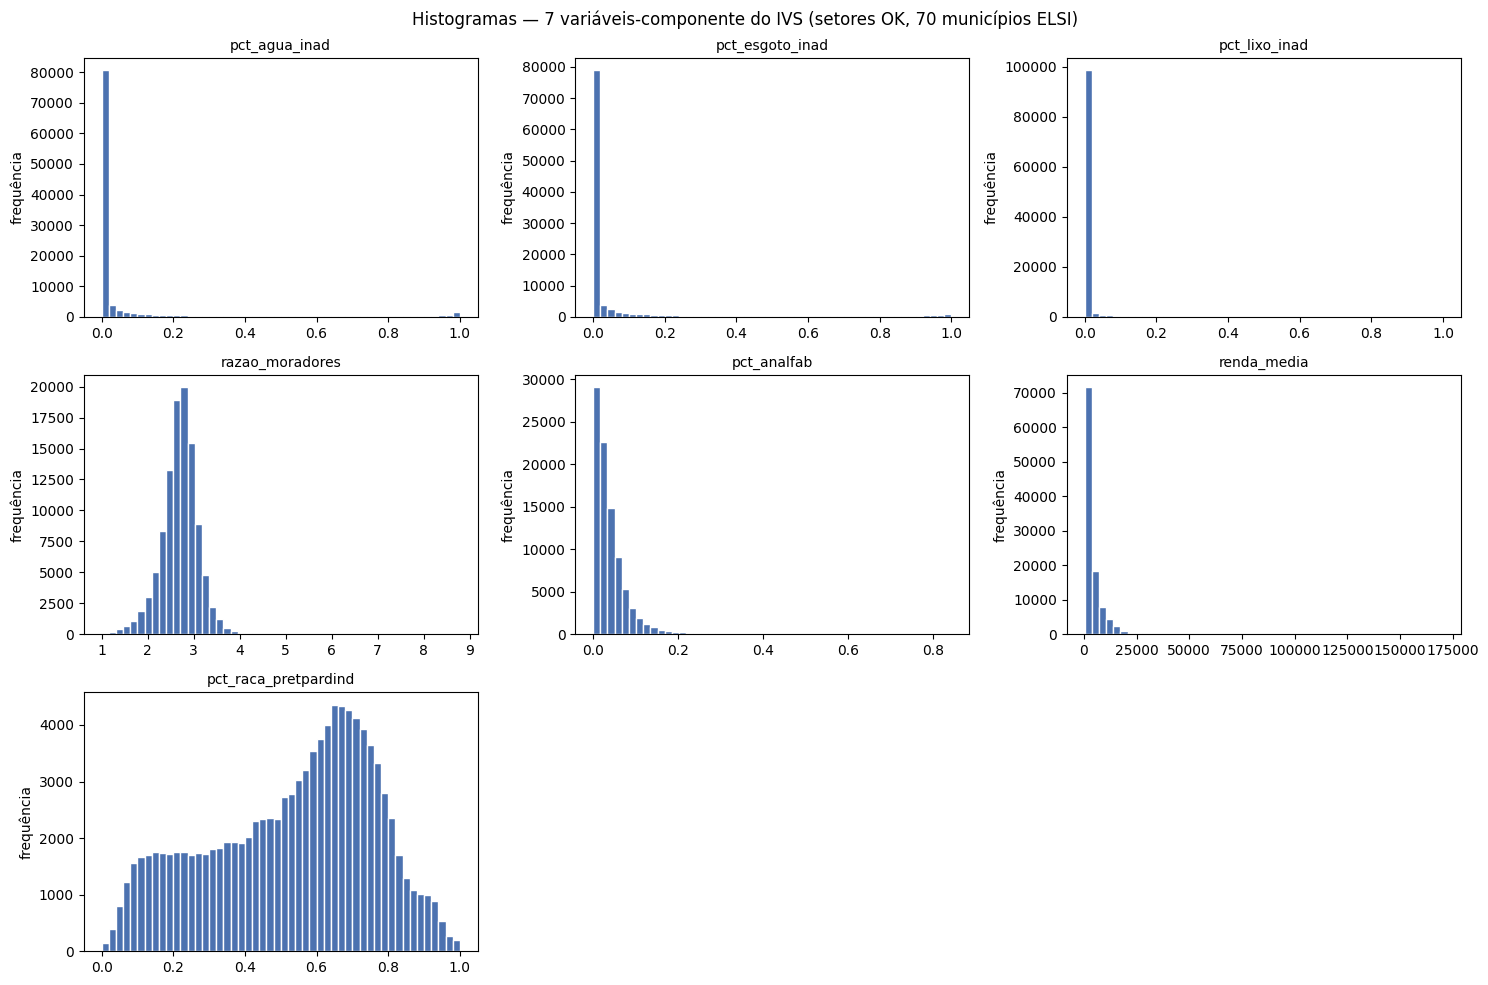

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(INDICADORES):
    ax = axes[i]
    df_ok[col].dropna().hist(bins=50, ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('frequência')
    ax.grid(False)
for j in range(len(INDICADORES), len(axes)):
    axes[j].axis('off')
fig.suptitle('Histogramas — 7 variáveis-componente do IVS (setores OK, 70 municípios ELSI)', fontsize=12)
fig.tight_layout()
fig.savefig(CAMINHO_FIG + 'histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Distribuições — boxplots por região

Boxplots estratificados por região (guia FIOCRUZ, Seção 5.3) para comparar centro,
dispersão e outliers entre regiões.

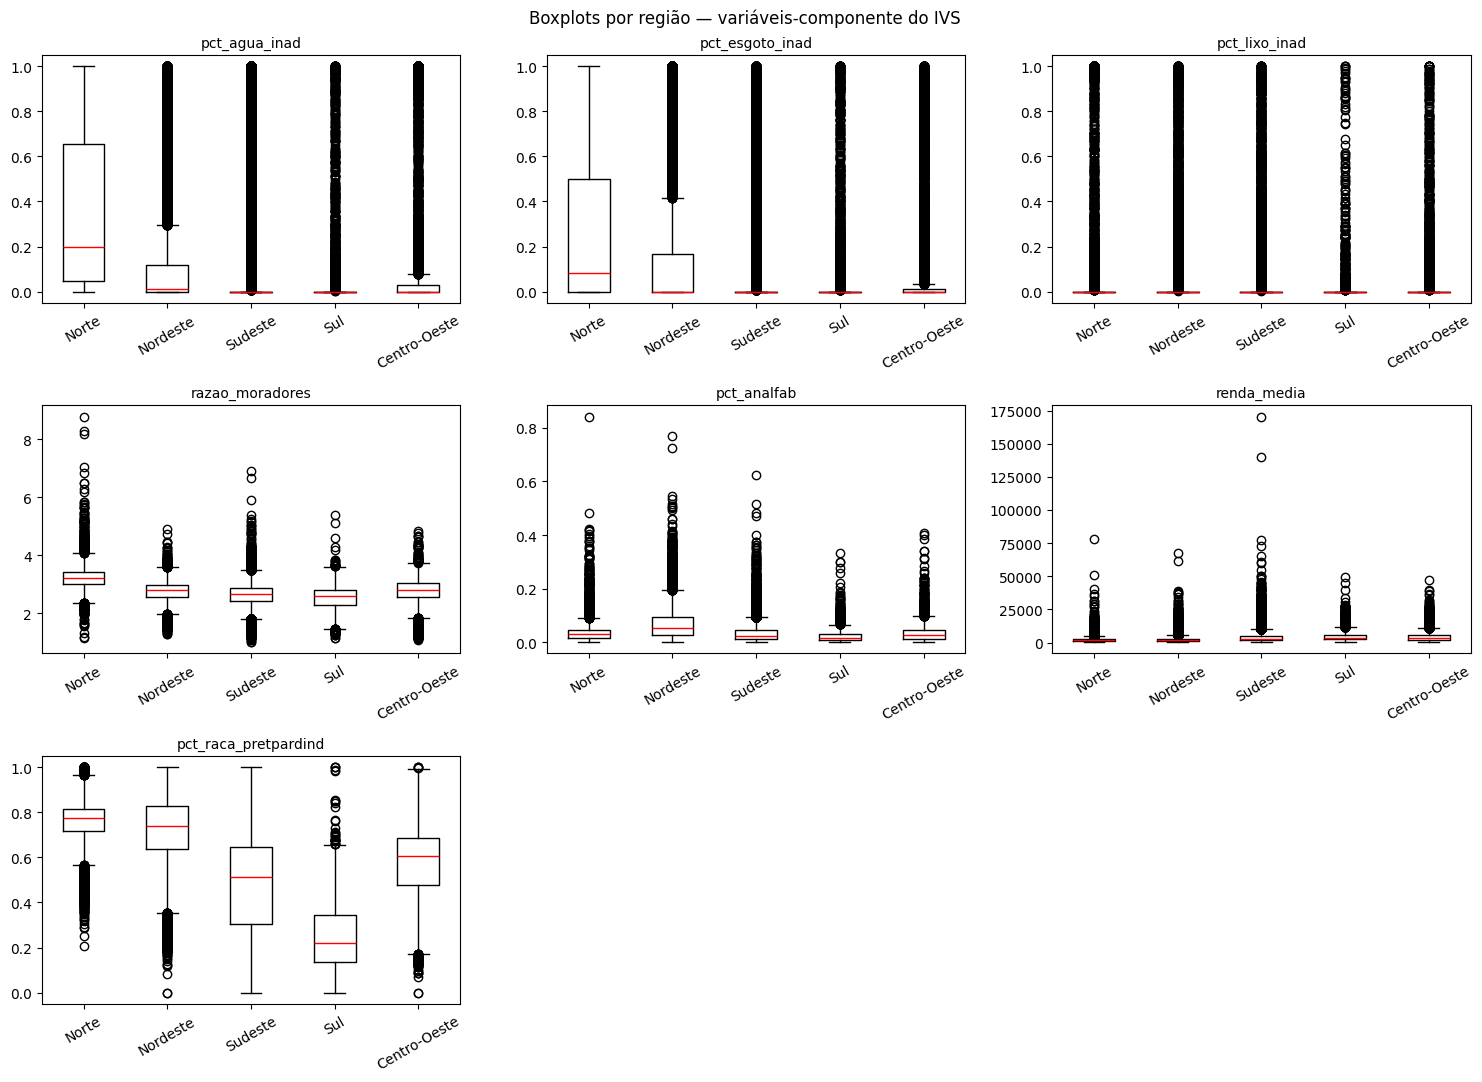

In [10]:
ordem_regiao = ['Norte','Nordeste','Sudeste','Sul','Centro-Oeste']
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for i, col in enumerate(INDICADORES):
    ax = axes[i]
    dados = [df_ok[df_ok['regiao'] == r][col].dropna() for r in ordem_regiao]
    ax.boxplot(dados, tick_labels=ordem_regiao, showfliers=True,
               medianprops={'color': 'red'})
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(False)
for j in range(len(INDICADORES), len(axes)):
    axes[j].axis('off')
fig.suptitle('Boxplots por região — variáveis-componente do IVS', fontsize=12)
fig.tight_layout()
fig.savefig(CAMINHO_FIG + 'boxplots_por_regiao.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Análise de outliers (regra do IQR)

Conta o número de setores fora do intervalo `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` para cada
variável (guia FIOCRUZ, Seção 5.3). Outliers não devem ser removidos automaticamente
nesta fase — apenas inventariados.

In [11]:
def conta_outliers(s):
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iq = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iq, q3 + 1.5*iq
    fora = ((s < lim_inf) | (s > lim_sup)).sum()
    p95 = s.quantile(0.95)
    n_p95 = int((s > p95).sum())
    # Flag: regra IQR é não-informativa quando P25 == mediana (distribuição
    # zero-inflada ou super-concentrada). Nestes casos, recomenda-se reportar
    # apenas o P95.
    iqr_inadequado = (q1 == s.median())
    return pd.Series({
        'n_validos':   int(len(s)),
        'q1': q1, 'q3': q3, 'iq': iq,
        'lim_inf': lim_inf, 'lim_sup': lim_sup,
        'n_outliers':  int(fora),
        'pct_outliers': round(fora / len(s) * 100, 2) if len(s) else np.nan,
        'p95': p95,
        'n_acima_p95':  n_p95,
        'pct_acima_p95': round(n_p95 / len(s) * 100, 2) if len(s) else np.nan,
        'iqr_nao_informativo': iqr_inadequado,
    })

outliers = pd.DataFrame({c: conta_outliers(df_ok[c]) for c in INDICADORES}).T
print('Outliers por variável — regra IQR (1.5 × IQR) + alternativa P95:\n')
print(outliers.round(4).to_string())
print('\nNota: `iqr_nao_informativo=True` indica distribuição zero-inflada;')
print('use n_acima_p95 / pct_acima_p95 em vez da regra IQR no relatório.')


Outliers por variável — regra IQR (1.5 × IQR) + alternativa P95:

                     n_validos         q1         q3        iq   lim_inf   lim_sup n_outliers pct_outliers        p95 n_acima_p95 pct_acima_p95 iqr_nao_informativo
pct_agua_inad           106281        0.0   0.016667  0.016667    -0.025  0.041667      21476        20.21   0.723906        5314           5.0                True
pct_esgoto_inad         106280        0.0   0.023256  0.023256 -0.034884   0.05814      21158        19.91   0.775201        5314           5.0                True
pct_lixo_inad           106276        0.0        0.0       0.0       0.0       0.0       9017         8.48   0.056458        5314           5.0                True
razao_moradores         106281   2.482353   2.931624  0.449271  1.808446   3.60553       3829          3.6   3.299652        5314           5.0               False
pct_analfab              89527   0.012914   0.051667  0.038753 -0.045215  0.109796       4696         5.25   0.111

## 11. Análise de dados faltantes

Mapa de calor da % de células faltantes em cada variável-componente, por município.
Indispensável para detectar municípios com cobertura ruim (guia FIOCRUZ, checklist
20.2).

Top 10 municípios com mais dados faltantes (média entre variáveis):
                     pct_agua_inad  pct_esgoto_inad  pct_lixo_inad  razao_moradores  pct_analfab  renda_media  pct_raca_pretpardind    _media
NM_MUN                                                                                                                                       
São Caetano do Sul             0.0              0.0           0.00              0.0        29.69         0.00                  0.00  4.241429
Porto Alegre                   0.0              0.0           0.00              0.0        27.46         0.00                  0.00  3.922857
Curitiba                       0.0              0.0           0.00              0.0        23.11         0.00                  0.00  3.301429
São Pedro da Aldeia            0.0              0.0           0.00              0.0        22.66         0.28                  0.00  3.277143
Belo Horizonte                 0.0              0.0           0.00              

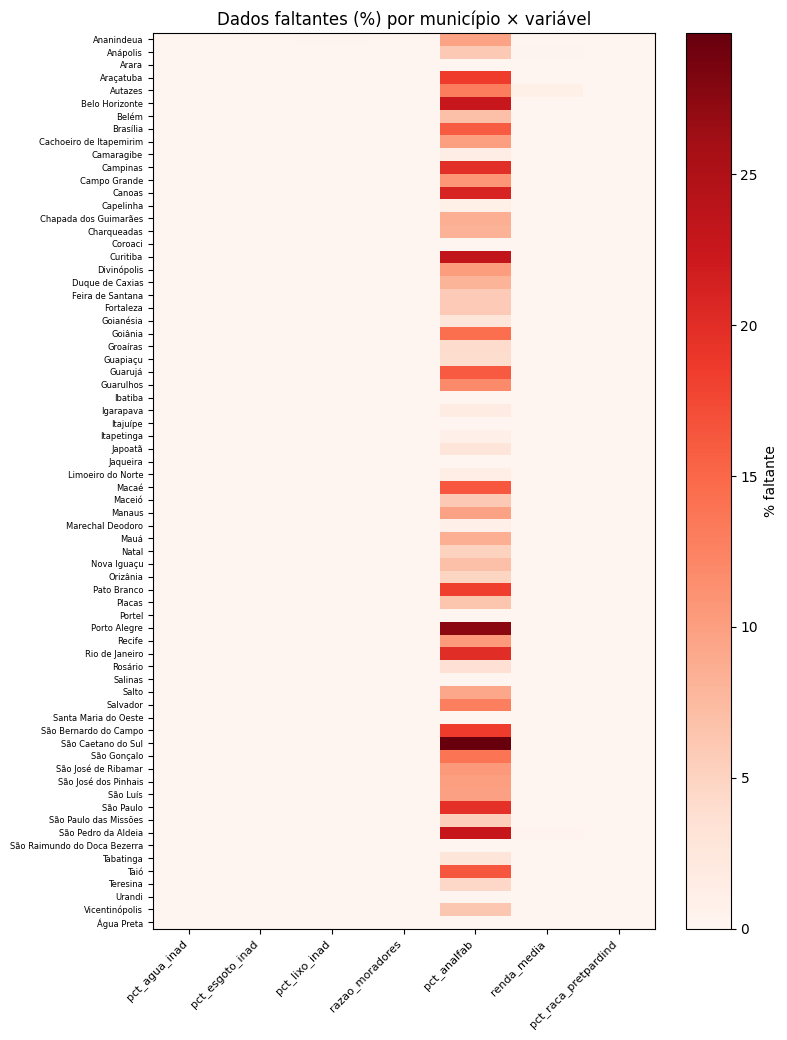

In [12]:
miss_mun = (df_ok.groupby('NM_MUN')[INDICADORES]
            .apply(lambda g: g.isna().mean() * 100)
            .round(2))
print('Top 10 municípios com mais dados faltantes (média entre variáveis):')
miss_mun['_media'] = miss_mun.mean(axis=1)
print(miss_mun.sort_values('_media', ascending=False).head(10).to_string())

fig, ax = plt.subplots(figsize=(8, max(8, len(miss_mun) * 0.15)))
m = miss_mun.drop(columns='_media').values
im = ax.imshow(m, aspect='auto', cmap='Reds', vmin=0, vmax=max(1, m.max()))
ax.set_yticks(range(len(miss_mun)))
ax.set_yticklabels(miss_mun.index, fontsize=6)
ax.set_xticks(range(len(INDICADORES)))
ax.set_xticklabels(INDICADORES, rotation=45, ha='right', fontsize=8)
fig.colorbar(im, ax=ax, label='% faltante')
ax.set_title('Dados faltantes (%) por município × variável')
fig.tight_layout()
fig.savefig(CAMINHO_FIG + 'missing_por_municipio.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Matriz de correlação

Correlação de Pearson (linear) e Spearman (postos / não paramétrica) entre as 7
variáveis (guia FIOCRUZ, Seção 11). Subsidia a futura análise fatorial — variáveis
muito correlacionadas tendem a se agrupar no mesmo fator.

Pearson:
                       pct_agua_inad  pct_esgoto_inad  pct_lixo_inad  razao_moradores  pct_analfab  renda_media  pct_raca_pretpardind
pct_agua_inad                 1.000            0.351          0.378            0.212        0.260       -0.120                 0.244
pct_esgoto_inad               0.351            1.000          0.368            0.285        0.442       -0.225                 0.320
pct_lixo_inad                 0.378            0.368          1.000            0.155        0.411       -0.111                 0.183
razao_moradores               0.212            0.285          0.155            1.000        0.317       -0.322                 0.475
pct_analfab                   0.260            0.442          0.411            0.317        1.000       -0.391                 0.489
renda_media                  -0.120           -0.225         -0.111           -0.322       -0.391        1.000                -0.680
pct_raca_pretpardind          0.244            0.320       

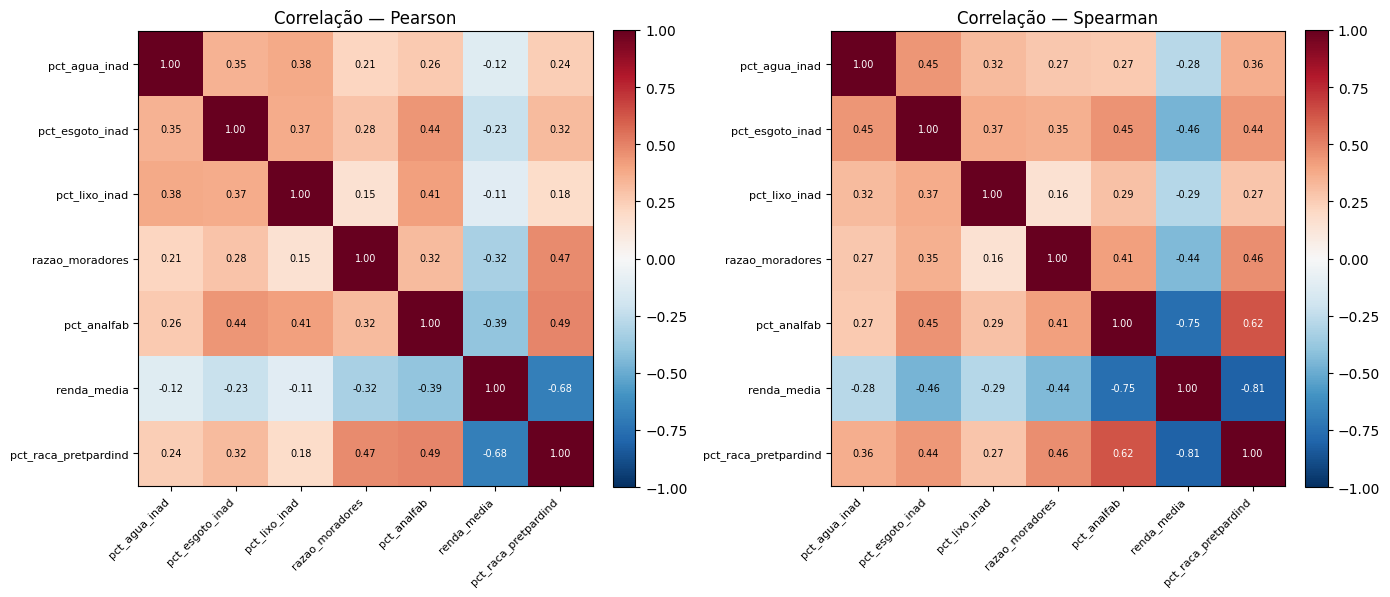

In [13]:
corr_p = df_ok[INDICADORES].corr(method='pearson').round(3)
corr_s = df_ok[INDICADORES].corr(method='spearman').round(3)

print('Pearson:\n', corr_p.to_string(), '\n')
print('Spearman:\n', corr_s.to_string())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 6))
for ax, mat, titulo in [(a1, corr_p, 'Pearson'), (a2, corr_s, 'Spearman')]:
    im = ax.imshow(mat.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(INDICADORES))); ax.set_yticks(range(len(INDICADORES)))
    ax.set_xticklabels(INDICADORES, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(INDICADORES, fontsize=8)
    ax.set_title(f'Correlação — {titulo}')
    for i in range(len(INDICADORES)):
        for j in range(len(INDICADORES)):
            ax.text(j, i, f'{mat.values[i,j]:.2f}', ha='center', va='center',
                    color='black' if abs(mat.values[i,j]) < 0.6 else 'white', fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(CAMINHO_FIG + 'matriz_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Exportação dos artefatos

Salva os CSVs com as tabelas descritivas em `banco_de_dados/eda/`. As figuras
já foram salvas em `banco_de_dados/eda/figuras/` ao longo das células anteriores.

In [14]:
desc_global.to_csv(CAMINHO_EDA + 'descritivas_globais.csv',       sep=';', encoding='utf-8-sig')
desc_mun.to_csv(   CAMINHO_EDA + 'descritivas_por_municipio.csv', sep=';', encoding='utf-8-sig', index=False)
desc_reg.to_csv(   CAMINHO_EDA + 'descritivas_por_regiao.csv',    sep=';', encoding='utf-8-sig', index=False)
outliers.to_csv(   CAMINHO_EDA + 'outliers.csv',                  sep=';', encoding='utf-8-sig')
miss_mun.drop(columns='_media').to_csv(CAMINHO_EDA + 'missing_por_municipio.csv',
                                        sep=';', encoding='utf-8-sig')
corr_p.to_csv(CAMINHO_EDA + 'correlacao_pearson.csv',  sep=';', encoding='utf-8-sig')
corr_s.to_csv(CAMINHO_EDA + 'correlacao_spearman.csv', sep=';', encoding='utf-8-sig')
resumo.to_csv(CAMINHO_EDA + 'elegibilidade_setores.csv', sep=';', encoding='utf-8-sig')

print('Artefatos exportados em', CAMINHO_EDA)
print('Figuras em', CAMINHO_FIG)

Artefatos exportados em D:\Iniciação Cientifica\Projeto_IVS_Censo22\banco_de_dados\eda\
Figuras em D:\Iniciação Cientifica\Projeto_IVS_Censo22\banco_de_dados\eda\figuras\
